<a href="https://colab.research.google.com/github/Hamasri/AI-Tools-analysis-Dashboard/blob/main/Supply_chain_optimation_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import sqlite3
!pip install faker
from faker import Faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.8 MB/s eta 0:00:00


In [2]:
#suppliers table
from faker import Faker
import random
fake=Faker()

suppliers=[]
for i in range (1,101):
  suppliers.append([
      i,
      fake.company(),
      round(random.uniform(2.5,5.0),1),
      fake.city()
  ])

suppliers_df=pd.DataFrame(
    suppliers,columns=[
        'Supplier_ID',
        'Supplier_Name',
        'Supplier_Rating',
        'Supplier_City'
    ]
)


#warehouses table
Warehouses=[]
for i in range (1,21):
  Warehouses.append([
      i,
      f"Warehouses_{i}",
      random.randint(1000,10000),
      fake.city()
  ])
Warehouses_df=pd.DataFrame(
    Warehouses,
    columns=[
        'Warehouse_ID',
        'Warehouse_Name',
        'Capacity',
        'Location'
    ]
    )

#Products table

Products=[]
Categories=[
    'Electronics',
    'Furniture',
    'Food',
    'Clothing'
]
for i in range(1,201):
  Products.append([
      i,
      fake.word(),
      random.choice(Categories),
      random.randint(100,5000)

  ])
  Products_df=pd.DataFrame(
      Products,
      columns=[
          'Product_ID',
          'Product_Name',
          'Category',
          'Unit_Price'
      ]
  )
  #orders_table

orders = []

for i in range(1, 1001):

    order_date = fake.date_between(
        start_date='-1y',
        end_date='today'
    )

    delivery_days = random.randint(1, 15)

    delivery_date = (
        pd.to_datetime(order_date)
        + pd.Timedelta(days=delivery_days)
    )

    status = (
        'Delayed'
        if delivery_days > 7
        else 'On Time'
    )

    orders.append([
        i,
        random.randint(1, 200),
        random.randint(1, 100),
        random.randint(1, 20),
        order_date,
        delivery_date,
        random.randint(1, 100),
        status
    ])

# OUTSIDE LOOP
orders_df = pd.DataFrame(
    orders,
    columns=[
        'Order_ID',
        'Product_ID',
        'Supplier_ID',
        'Warehouse_ID',
        'Order_Date',
        'Delivery_Date',
        'Quantity',
        'Delivery_Status'
    ]
)

#inventory table
inventory=[]
for i in range(1,5001):
  inventory.append([
      i,
      random.randint(1,20),
      random.randint(1,200),
      random.randint(0,500),
      random.randint(50,100)
  ])
inventory_df=pd.DataFrame(
    inventory,
    columns=[
        'Inventory_ID',
        'Warehouse_ID',
        'Product_ID',
        'Stock_LeveL',
        'Reorder_Level'
    ]
)

#export to csv
suppliers_df.to_csv('Suppliers.csv',index=False)
Warehouses_df.to_csv('Warehouse.csv',index=False)
Products_df.to_csv('Products.csv',index=False)
orders_df.to_csv('Orders.csv',index=False)
inventory_df.to_csv('inventory.csv',index=False)








In [3]:
import sqlite3
conn=sqlite3.connect('supply_chain.db')
cursor=conn.cursor()

#Load DataFrames into SQL Tables
orders_df.to_sql('Orders',conn,if_exists='replace',index=False)
Products_df.to_sql('Products',conn,if_exists='replace',index=False)
suppliers_df.to_sql('Suppliers',conn,if_exists='replace',index=False)
Warehouses_df.to_sql('Warehouse',conn,if_exists='replace',index=False)
inventory_df.to_sql('inventory',conn,if_exists='replace',index=False)




5000

In [4]:
#Total orders per product
query="""
select Product_ID,COUNT(Order_ID) as Total_Orders
from Orders
GROUP BY Product_ID
ORDER BY Total_Orders desc;
"""
result=pd.read_sql_query(query,conn)
print(result)

     Product_ID  Total_Orders
0           193            12
1           102            10
2            45            10
3           121             9
4           112             9
..          ...           ...
195         145             1
196         110             1
197          96             1
198          79             1
199          12             1

[200 rows x 2 columns]


In [5]:
#Top suppliers by Rating
query="""
select Supplier_Name,Supplier_Rating from Suppliers
ORDER BY Supplier_Rating desc
limit 10;
"""
result=pd.read_sql_query(query,conn)
print(result)


              Supplier_Name  Supplier_Rating
0             Obrien-Tanner              5.0
1  Brown, Edwards and Jones              4.9
2              Faulkner LLC              4.9
3    Hardy, Wood and Barber              4.9
4             Gomez-Parsons              4.9
5                 Ramos LLC              4.9
6               Brown-Davis              4.9
7    Lewis, Ochoa and Smith              4.8
8       Dickerson-Armstrong              4.8
9              Butler-Boyle              4.8


In [6]:
#delayed orders count
query="""
select Delivery_Status,count(*) as Total_Orders
from Orders GROUP BY Delivery_Status;
"""
result=pd.read_sql_query(query,conn)
print(result)

  Delivery_Status  Total_Orders
0         Delayed           532
1         On Time           468


In [7]:
#warehouse capacity analysis
query="""
select Warehouse_Name,Capacity from Warehouse
ORDER BY Capacity desc;
"""
result=pd.read_sql_query(query,conn)
print(result)

   Warehouse_Name  Capacity
0   Warehouses_20      8832
1    Warehouses_3      7955
2    Warehouses_5      7322
3    Warehouses_9      6892
4   Warehouses_17      6682
5    Warehouses_2      6662
6   Warehouses_18      6092
7   Warehouses_15      5520
8    Warehouses_6      4731
9   Warehouses_12      4534
10   Warehouses_4      4397
11   Warehouses_1      4114
12  Warehouses_10      4058
13   Warehouses_7      3568
14  Warehouses_16      2917
15  Warehouses_13      2739
16  Warehouses_19      2424
17  Warehouses_14      1591
18   Warehouses_8      1571
19  Warehouses_11      1307


In [8]:
#Low stock products
query="""
select Inventory_ID,Product_ID,Stock_Level,Reorder_Level
from Inventory
WHERE Stock_Level < Reorder_Level;
"""
result=pd.read_sql_query(query,conn)
print(result)

     Inventory_ID  Product_ID  Stock_LeveL  Reorder_Level
0              15         190           45             65
1              22         185           43             92
2              30          86           77             88
3              31          92           12             83
4              33          92            6             79
..            ...         ...          ...            ...
733          4918          25           13             86
734          4973         193           56             99
735          4981         167           34             98
736          4982          90           15             83
737          4983           9            2             95

[738 rows x 4 columns]


In [9]:
#Category_wise product count
query="""
select Category,count(*) as Product_Count
from Products
GROUP BY Category;
"""
result=pd.read_sql_query(query,conn)
print(result)

      Category  Product_Count
0     Clothing             43
1  Electronics             60
2         Food             42
3    Furniture             55


In [10]:
#Average_delivery_Days
query="""
select avg(Julianday(Delivery_Date)-Julianday(Order_Date))as
Avg_Delivery_Days from Orders;
"""
result=pd.read_sql_query(query,conn)
print(result)

   Avg_Delivery_Days
0              8.051


In [11]:
#Most ordered Products
query="""
select Product_ID,sum(Quantity) as Total_Quantity
from Orders
GROUP BY Product_ID
ORDER BY Total_Quantity desc;
"""
result=pd.read_sql_query(query,conn)
print(result)

     Product_ID  Total_Quantity
0           193             598
1            59             533
2            14             532
3            43             524
4           182             509
..          ...             ...
195         198              44
196         145              42
197         126              29
198          67              23
199          96               8

[200 rows x 2 columns]


In [12]:
#Inventory Distribution by Warehouse
query="""
select Warehouse_ID,sum(Stock_Level) as Total_Stock
from Inventory
GROUP BY Warehouse_ID
ORDER BY Total_Stock Desc;
"""
result=pd.read_sql_query(query,conn)
print(result)

    Warehouse_ID  Total_Stock
0             16        72317
1              2        68059
2             10        67890
3             12        67431
4              5        66503
5             11        65047
6              1        63921
7              4        63801
8             20        63784
9             17        63571
10             8        62195
11            15        62178
12             9        61428
13            13        60573
14             7        60217
15             3        60128
16            14        59845
17             6        56901
18            19        56619
19            18        54228


In [13]:
#join queries
query="""
select p.Product_Name,s.Supplier_Name,sum(o.Quantity) as Total_Quantity
from Orders o join Products p on
o.Product_ID = p.Product_ID join
Suppliers s on
o.Supplier_ID = s.Supplier_ID
GROUP BY p.Product_Name,s.Supplier_Name
ORDER BY Total_Quantity desc
Limit 10;
"""
result=pd.read_sql_query(query,conn)
print(result)

  Product_Name                 Supplier_Name  Total_Quantity
0     positive   Matthews, Kramer and Garcia             166
1      receive  Thomas, Cisneros and Patrick             156
2        plant     Thomas, Welch and Hopkins             155
3          bar                 Alexander PLC             149
4   discussion        Hardy, Wood and Barber             149
5    authority                   Olson-Reyes             148
6        sense   Carter, Martin and Thompson             148
7         room                Pennington Ltd             140
8      history               Stephenson-Chen             137
9         find                   Fischer Inc             134


In [14]:
#Find delayed vs on-time deliveries.
query="""

Select
    Delivery_Status,
    COUNT(*) AS Total_Orders,
    ROUND(
        COUNT(*) * 100.0 / (
            SELECT COUNT(*) FROM Orders
        ),
        2
    ) AS Percentage
FROM Orders
GROUP BY Delivery_Status;
"""
result=pd.read_sql_query(query,conn)
print(result)

  Delivery_Status  Total_Orders  Percentage
0         Delayed           532        53.2
1         On Time           468        46.8


In [15]:
#Check stock stored in each warehouse.
query="""

SELECT
    w.Warehouse_Name,
    w.Capacity,
    SUM(i.Stock_Level) AS Total_Stock,
    ROUND(
        SUM(i.Stock_Level) * 100.0 / w.Capacity,
        2
    ) AS Utilization_Percentage
FROM Warehouse w
JOIN Inventory i
ON w.Warehouse_ID = i.Warehouse_ID
GROUP BY w.Warehouse_ID
ORDER BY Utilization_Percentage DESC;
"""
result=pd.read_sql_query(query,conn)
print(result)

   Warehouse_Name  Capacity  Total_Stock  Utilization_Percentage
0   Warehouses_11      1307        65047                 4976.82
1    Warehouses_8      1571        62195                 3958.94
2   Warehouses_14      1591        59845                 3761.47
3   Warehouses_16      2917        72317                 2479.16
4   Warehouses_19      2424        56619                 2335.77
5   Warehouses_13      2739        60573                 2211.50
6    Warehouses_7      3568        60217                 1687.70
7   Warehouses_10      4058        67890                 1672.99
8    Warehouses_1      4114        63921                 1553.74
9   Warehouses_12      4534        67431                 1487.23
10   Warehouses_4      4397        63801                 1451.01
11   Warehouses_6      4731        56901                 1202.73
12  Warehouses_15      5520        62178                 1126.41
13   Warehouses_2      6662        68059                 1021.60
14  Warehouses_17      66

In [16]:
#Products needing immediate reorder.
query="""

SELECT
    Product_ID,
    COUNT(*) AS Reorder_Count
FROM Inventory
WHERE Stock_Level < Reorder_Level
GROUP BY Product_ID
ORDER BY Reorder_Count DESC;
"""
result=pd.read_sql_query(query,conn)
print(result)

     Product_ID  Reorder_Count
0           148              9
1           194              8
2           110              8
3            86              8
4           200              7
..          ...            ...
191          48              1
192          35              1
193          31              1
194          16              1
195          12              1

[196 rows x 2 columns]


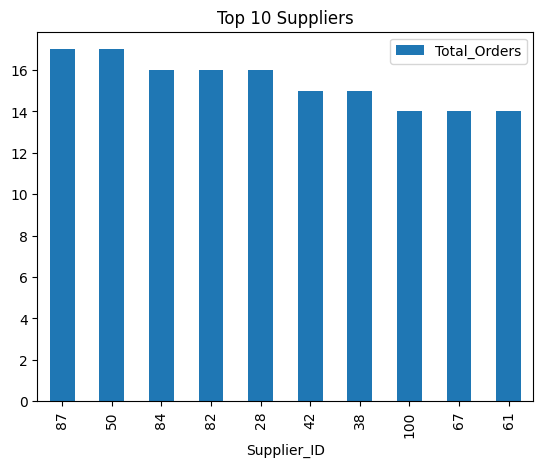

In [19]:
import matplotlib.pyplot as plt
#Supplier Performance chart
query="""
select supplier_ID,count(*) as Total_Orders from orders
GROUP BY Supplier_ID
ORDER BY Total_Orders desc
limit 10
"""
top_supplier_df=pd.read_sql_query(query,conn)

top_supplier_df.plot(
    x='Supplier_ID',
    y='Total_Orders',
    kind='bar'
)
plt.title('Top 10 Suppliers')
plt.show()
